# Non-Ergodic Mess3 Experiment
## Factored Representations in Transformers Trained on Mixtures of HMMs

**Goal:** Train small transformers on non-ergodic mixtures of Mess3 processes and analyze whether residual stream geometry matches factored representation predictions.

**Key prediction:** Activations should organize into K+1 effective dimensions — K-1 for component identity + 2 for within-component belief state — in orthogonal subspaces.

**References:**
- Shai et al. (2024). "Transformers Represent Belief State Geometry in their Residual Stream." NeurIPS 2024.
- Shai et al. (2026). "Transformers Learn Factored Representations." arXiv:2602.02385
- Xie et al. (2022). "An Explanation of In-Context Learning as Implicit Bayesian Inference." ICLR 2022.

In [20]:
# Cell 1: Install dependencies
# Align with Colab's default Numpy 2.x stack to avoid version conflicts
# !pip install -U "numpy>=2.0" "scipy>=1.13" "scikit-learn>=1.5" transformer_lens einops transformers==4.37.2

import torch
import numpy as np
print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    DEVICE = "cuda"
else:
    print("WARNING: No GPU detected. Training will be slow.")
    DEVICE = "cpu"

PyTorch: 2.10.0+cu128
NumPy: 1.26.4
CUDA available: True
GPU: NVIDIA GeForce RTX 5090


## 1. Data Generation — Mess3 Process & Non-Ergodic Dataset

The Mess3 process is a 3-state HMM with deterministic emission (state i emits token i) and transition matrix parameterized by p:

```
T(p) = [[1-p,  p/2,  p/2],
         [p/2,  1-p,  p/2],
         [p/2,  p/2,  1-p]]
```

Our non-ergodic dataset is a **mixture of K Mess3 processes** with different p values. Each sequence comes entirely from one component.

In [2]:
import numpy as np
from typing import List, Tuple, Dict, Optional
from dataclasses import dataclass, field
import torch
import torch.nn.functional as F
from pathlib import Path
import json
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

# ============================================================
# DATA GENERATION
# ============================================================

class Mess3Process:
    """A single Mess3 Hidden Markov Model with parameter p."""
    def __init__(self, p: float):
        self.p = p
        self.transition_matrix = self._build_transition_matrix(p)
        self.stationary_dist = np.array([1/3, 1/3, 1/3])

    @staticmethod
    def _build_transition_matrix(p: float) -> np.ndarray:
        T = np.full((3, 3), p / 2)
        np.fill_diagonal(T, 1 - p)
        return T

    def generate_sequence(self, length: int) -> Tuple[List[int], List[int]]:
        state = np.random.choice(3, p=self.stationary_dist)
        states, tokens = [], []
        for _ in range(length):
            states.append(state)
            tokens.append(state)  # Deterministic emission
            state = np.random.choice(3, p=self.transition_matrix[state])
        return tokens, states


class NonErgodicDataset:
    """Non-ergodic mixture of K Mess3 processes."""
    def __init__(self, p_values: List[float], seq_len: int = 16):
        self.processes = [Mess3Process(p) for p in p_values]
        self.p_values = p_values
        self.K = len(p_values)
        self.seq_len = seq_len

    def sample_batch(self, batch_size: int) -> Tuple[torch.Tensor, torch.Tensor]:
        all_tokens, comp_ids = [], []
        for _ in range(batch_size):
            k = np.random.randint(self.K)
            toks, _ = self.processes[k].generate_sequence(self.seq_len)
            shifted = [t + 1 for t in toks]  # Reserve 0 for BOS
            all_tokens.append([0] + shifted)
            comp_ids.append(k)
        return (torch.tensor(all_tokens, dtype=torch.long),
                torch.tensor(comp_ids, dtype=torch.long))


def compute_belief_states(tokens: torch.Tensor, p_values: List[float], bos_token: int = 0) -> torch.Tensor:
    """Compute predictive belief states: P(next_hidden_state | component=k, x_{1:t}).
    Returns: (batch, seq_len, K, 3)"""
    batch_size, seq_len = tokens.shape
    K = len(p_values)
    processes = [Mess3Process(p) for p in p_values]
    beliefs = torch.zeros(batch_size, seq_len, K, 3)
    for b in range(batch_size):
        for ki, proc in enumerate(processes):
            for t in range(seq_len):
                tok = tokens[b, t].item()
                if tok == bos_token:
                    beliefs[b, t, ki] = torch.tensor([1/3, 1/3, 1/3])
                else:
                    beliefs[b, t, ki] = torch.tensor(proc.transition_matrix[tok - 1])
    return beliefs


def compute_component_posterior(tokens: torch.Tensor, p_values: List[float], bos_token: int = 0) -> torch.Tensor:
    """Compute P(component=k | x_{1:t}) via Bayesian updating. Returns: (batch, seq_len, K)"""
    batch_size, seq_len = tokens.shape
    K = len(p_values)
    processes = [Mess3Process(p) for p in p_values]
    posterior = torch.zeros(batch_size, seq_len, K)
    for b in range(batch_size):
        log_prior = np.log(np.ones(K) / K)
        beliefs = [np.array([1/3, 1/3, 1/3]) for _ in range(K)]
        for t in range(seq_len):
            tok = tokens[b, t].item()
            if tok == bos_token:
                log_post = log_prior.copy()
            else:
                observed_state = tok - 1
                for ki in range(K):
                    log_prior[ki] += np.log(beliefs[ki][observed_state] + 1e-30)
                    beliefs[ki] = processes[ki].transition_matrix[observed_state]
                log_post = log_prior.copy()
            log_post_shifted = log_post - np.max(log_post)
            post = np.exp(log_post_shifted)
            post /= post.sum()
            posterior[b, t] = torch.tensor(post)
    return posterior

# Quick sanity check
proc = Mess3Process(p=0.3)
print(f"Transition matrix (p=0.3):\n{proc.transition_matrix}")
print(f"Row sums: {proc.transition_matrix.sum(axis=1)}")
ds = NonErgodicDataset(p_values=[0.1, 0.9], seq_len=8)
toks, cids = ds.sample_batch(4)
print(f"\nSample batch shape: {toks.shape}, component_ids: {cids.tolist()}")
print(f"Sample tokens:\n{toks}")

Transition matrix (p=0.3):
[[0.7  0.15 0.15]
 [0.15 0.7  0.15]
 [0.15 0.15 0.7 ]]
Row sums: [1. 1. 1.]

Sample batch shape: torch.Size([4, 9]), component_ids: [0, 0, 0, 1]
Sample tokens:
tensor([[0, 3, 3, 3, 3, 3, 3, 2, 2],
        [0, 2, 2, 2, 2, 2, 1, 1, 1],
        [0, 3, 3, 3, 1, 1, 1, 1, 1],
        [0, 3, 2, 3, 1, 1, 3, 1, 3]])


## 2. Model — TransformerLens GPT-2 Style

In [3]:
import torch
import torch.nn.functional as F

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
from transformer_lens import HookedTransformer, HookedTransformerConfig

# ============================================================
# MODEL
# ============================================================

def create_model(n_layers=2, d_model=64, d_mlp=256, n_heads=4, n_ctx=16, d_vocab=4, device="cpu"):
    cfg = HookedTransformerConfig(
        n_layers=n_layers, d_model=d_model, d_head=d_model // n_heads,
        d_mlp=d_mlp, n_heads=n_heads, n_ctx=n_ctx, d_vocab=d_vocab,
        act_fn="gelu", normalization_type="LN",
    )
    model = HookedTransformer(cfg).to(device)
    return model

def train_step(model, optimizer, tokens):
    model.train()
    logits = model(tokens[:, :-1])
    targets = tokens[:, 1:]
    loss = F.cross_entropy(logits.reshape(-1, logits.shape[-1]), targets.reshape(-1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

def extract_activations(model, tokens):
    """Returns dict: layer_name -> (batch, seq_len, d_model)"""
    model.eval()
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens)
    activations = {}
    activations["embed"] = cache["hook_embed"]
    if "hook_pos_embed" in cache:
        activations["embed"] = activations["embed"] + cache["hook_pos_embed"]
    for i in range(model.cfg.n_layers):
        activations[f"layer{i}"] = cache[f"blocks.{i}.hook_resid_post"]
    activations["final"] = activations[f"layer{model.cfg.n_layers - 1}"]
    return activations

# Quick test
m = create_model(n_layers=1, d_model=32, d_mlp=128, n_heads=2, n_ctx=8, device=DEVICE)
test_tok = torch.randint(0, 4, (2, 8)).to(DEVICE)
print(f"Model output shape: {m(test_tok).shape}")
acts = extract_activations(m, test_tok)
print(f"Activation layers: {list(acts.keys())}")
print(f"Final activations shape: {acts['final'].shape}")
del m, test_tok, acts
torch.cuda.empty_cache() if DEVICE == "cuda" else None

Moving model to device:  cuda
Model output shape: torch.Size([2, 8, 4])
Activation layers: ['embed', 'layer0', 'final']
Final activations shape: torch.Size([2, 8, 32])


## 3. Experiment Configs

We sweep K ∈ {2, 4, 8} with 3 seeds each. Each config defines the Mess3 p-values, model architecture, and training hyperparameters.

In [4]:
# ============================================================
# EXPERIMENT CONFIGS
# ============================================================

EXPERIMENTS = {
    "K2": {"p_values": [0.1, 0.9]},
    "K4": {"p_values": [0.1, 0.3, 0.7, 0.9]},
    "K8": {"p_values": [0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9]},
}

# Shared hyperparameters
SEQ_LEN = 16
N_LAYERS = 2
D_MODEL = 64
D_MLP = 256
N_HEADS = 4
BATCH_SIZE = 256
N_STEPS = 10_000
LR = 1e-3
CHECKPOINT_EVERY = 500   # Save checkpoints for training dynamics
N_SEEDS = 3
N_TEST = 10_000          # Test sequences for analysis

print("Experiment configurations:")
for name, cfg in EXPERIMENTS.items():
    K = len(cfg["p_values"])
    print(f"  {name}: K={K}, p_values={cfg['p_values']}")
    print(f"    Factored prediction: {K+1} dims | Joint prediction: {3*K-1} dims")

Experiment configurations:
  K2: K=2, p_values=[0.1, 0.9]
    Factored prediction: 3 dims | Joint prediction: 5 dims
  K4: K=4, p_values=[0.1, 0.3, 0.7, 0.9]
    Factored prediction: 5 dims | Joint prediction: 11 dims
  K8: K=8, p_values=[0.1, 0.2, 0.3, 0.4, 0.6, 0.7, 0.8, 0.9]
    Factored prediction: 9 dims | Joint prediction: 23 dims


## 4. Training Loop

Trains all experiments (K=2,4,8 × 3 seeds). Saves checkpoints for training dynamics analysis. Stores final models and loss curves.

In [5]:
# ============================================================
# TRAINING
# ============================================================

all_results = {}  # Store everything: models, losses, activations, analyses

for exp_name, exp_cfg in EXPERIMENTS.items():
    p_values = exp_cfg["p_values"]
    K = len(p_values)
    all_results[exp_name] = {"p_values": p_values, "K": K, "seeds": {}}

    for seed in range(N_SEEDS):
        run_name = f"{exp_name}_seed{seed}"
        print(f"\n{'='*60}")
        print(f"Training {run_name} | K={K}, p={p_values}")
        print(f"{'='*60}")

        torch.manual_seed(seed)
        np.random.seed(seed)

        dataset = NonErgodicDataset(p_values=p_values, seq_len=SEQ_LEN)
        model = create_model(
            n_layers=N_LAYERS, d_model=D_MODEL, d_mlp=D_MLP,
            n_heads=N_HEADS, n_ctx=SEQ_LEN + 1, d_vocab=4, device=DEVICE,
        )
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_STEPS)

        losses = []
        checkpoints = {}  # step -> state_dict

        for step in range(N_STEPS):
            tokens, comp_ids = dataset.sample_batch(BATCH_SIZE)
            tokens = tokens.to(DEVICE)
            loss = train_step(model, optimizer, tokens)
            scheduler.step()
            losses.append(loss)

            if step % 500 == 0:
                print(f"  Step {step:5d}/{N_STEPS} | Loss: {loss:.4f}")

            if step % CHECKPOINT_EVERY == 0 or step == N_STEPS - 1:
                checkpoints[step] = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        # Store results for this seed
        all_results[exp_name]["seeds"][seed] = {
            "losses": losses,
            "checkpoints": checkpoints,
            "final_state_dict": {k: v.cpu().clone() for k, v in model.state_dict().items()},
        }
        del model, optimizer, scheduler
        torch.cuda.empty_cache() if DEVICE == "cuda" else None

print("\n\nTraining complete for all experiments!")


Training K2_seed0 | K=2, p=[0.1, 0.9]
Moving model to device:  cuda
  Step     0/10000 | Loss: 1.4519
  Step   500/10000 | Loss: 0.7098
  Step  1000/10000 | Loss: 0.7378
  Step  1500/10000 | Loss: 0.7533
  Step  2000/10000 | Loss: 0.7383
  Step  2500/10000 | Loss: 0.7105
  Step  3000/10000 | Loss: 0.7450
  Step  3500/10000 | Loss: 0.7504
  Step  4000/10000 | Loss: 0.7567
  Step  4500/10000 | Loss: 0.7803
  Step  5000/10000 | Loss: 0.7593
  Step  5500/10000 | Loss: 0.7475
  Step  6000/10000 | Loss: 0.7038
  Step  6500/10000 | Loss: 0.7485
  Step  7000/10000 | Loss: 0.7221
  Step  7500/10000 | Loss: 0.7586
  Step  8000/10000 | Loss: 0.7388
  Step  8500/10000 | Loss: 0.7463
  Step  9000/10000 | Loss: 0.7317
  Step  9500/10000 | Loss: 0.7509

Training K2_seed1 | K=2, p=[0.1, 0.9]
Moving model to device:  cuda
  Step     0/10000 | Loss: 1.2876
  Step   500/10000 | Loss: 0.7632
  Step  1000/10000 | Loss: 0.7582
  Step  1500/10000 | Loss: 0.7564
  Step  2000/10000 | Loss: 0.7540
  Step  2500

## 5. Analysis A — Loss Curves

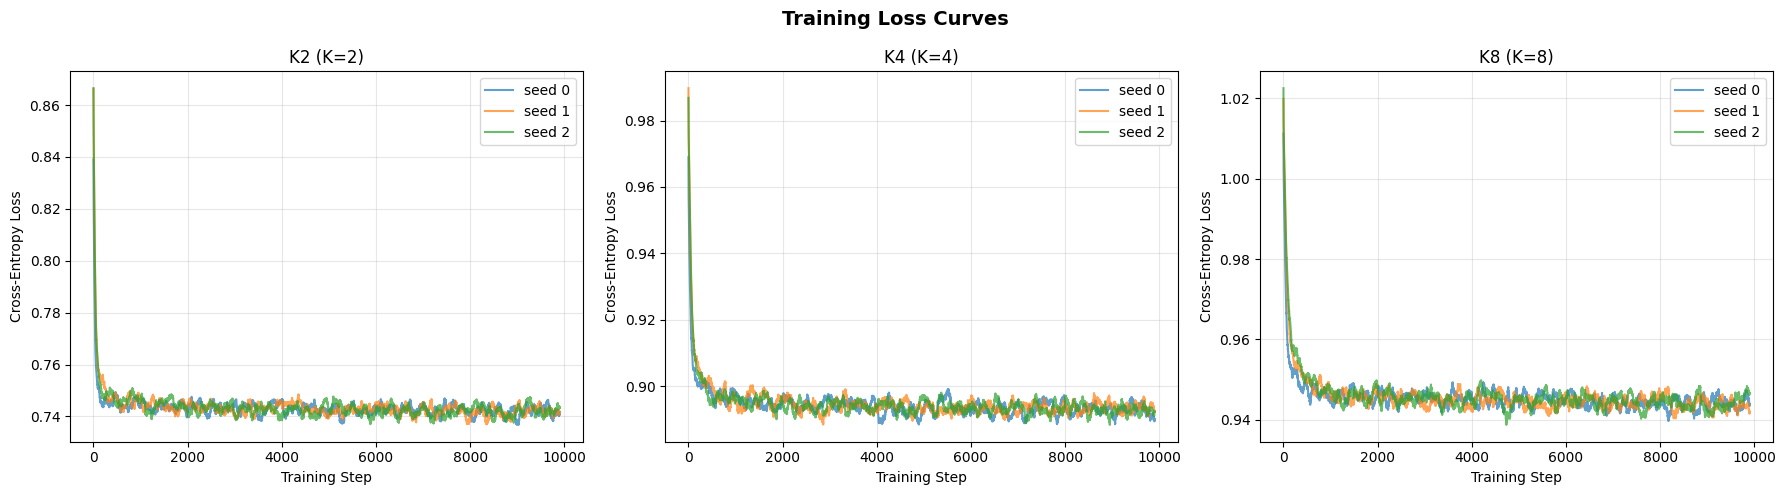

Saved: fig_loss_curves.pdf


In [6]:
# ============================================================
# ANALYSIS A: LOSS CURVES
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (exp_name, res) in enumerate(all_results.items()):
    ax = axes[idx]
    for seed in range(N_SEEDS):
        losses = res["seeds"][seed]["losses"]
        # Smoothed loss
        window = 100
        smoothed = np.convolve(losses, np.ones(window)/window, mode="valid")
        ax.plot(smoothed, alpha=0.7, label=f"seed {seed}")
    ax.set_title(f"{exp_name} (K={res['K']})")
    ax.set_xlabel("Training Step")
    ax.set_ylabel("Cross-Entropy Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle("Training Loss Curves", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_loss_curves.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_loss_curves.pdf")

## 6. Collect Activations & Ground Truth for All Experiments

Extract residual stream activations from trained models, compute ground-truth belief states and component posteriors.

In [7]:
# ============================================================
# COLLECT ACTIVATIONS & GROUND TRUTH (seed 0 only for main analyses)
# ============================================================

for exp_name, res in all_results.items():
    p_values = res["p_values"]
    K = res["K"]
    seed = 0  # Primary seed for detailed analysis

    print(f"\n--- Collecting activations for {exp_name} (seed 0) ---")
    torch.manual_seed(999)  # Fixed test seed
    np.random.seed(999)

    dataset = NonErgodicDataset(p_values=p_values, seq_len=SEQ_LEN)
    test_tokens, test_comp_ids = dataset.sample_batch(N_TEST)

    # Reload model
    model = create_model(
        n_layers=N_LAYERS, d_model=D_MODEL, d_mlp=D_MLP,
        n_heads=N_HEADS, n_ctx=SEQ_LEN + 1, d_vocab=4, device=DEVICE,
    )
    model.load_state_dict(res["seeds"][seed]["final_state_dict"])
    model.to(DEVICE)

    # Extract activations in batches to avoid OOM
    all_acts = {f"layer{i}": [] for i in range(N_LAYERS)}
    all_acts["embed"] = []
    all_acts["final"] = []

    batch_sz = 1000
    for start in range(0, N_TEST, batch_sz):
        end = min(start + batch_sz, N_TEST)
        batch_tokens = test_tokens[start:end].to(DEVICE)
        acts = extract_activations(model, batch_tokens)
        for key in all_acts:
            all_acts[key].append(acts[key].cpu())

    for key in all_acts:
        all_acts[key] = torch.cat(all_acts[key], dim=0)

    # Ground truth
    print(f"  Computing belief states...")
    beliefs = compute_belief_states(test_tokens, p_values)
    print(f"  Computing component posteriors...")
    comp_posterior = compute_component_posterior(test_tokens, p_values)

    # Store
    res["seeds"][seed]["test_tokens"] = test_tokens
    res["seeds"][seed]["test_comp_ids"] = test_comp_ids
    res["seeds"][seed]["activations"] = all_acts
    res["seeds"][seed]["beliefs"] = beliefs
    res["seeds"][seed]["comp_posterior"] = comp_posterior

    del model
    torch.cuda.empty_cache() if DEVICE == "cuda" else None
    print(f"  Done. Activations shape: {all_acts['final'].shape}")

print("\nAll activations collected!")


--- Collecting activations for K2 (seed 0) ---
Moving model to device:  cuda
Moving model to device:  cuda
  Computing belief states...
  Computing component posteriors...
  Done. Activations shape: torch.Size([10000, 17, 64])

--- Collecting activations for K4 (seed 0) ---
Moving model to device:  cuda
Moving model to device:  cuda
  Computing belief states...
  Computing component posteriors...
  Done. Activations shape: torch.Size([10000, 17, 64])

--- Collecting activations for K8 (seed 0) ---
Moving model to device:  cuda
Moving model to device:  cuda
  Computing belief states...
  Computing component posteriors...
  Done. Activations shape: torch.Size([10000, 17, 64])

All activations collected!


## 7. Analysis B — Dimensionality (PCA / Cumulative Explained Variance)

**Prediction:** Effective dimensionality at 95% CEV should be ~K+1 (factored), not 3K-1 (joint).

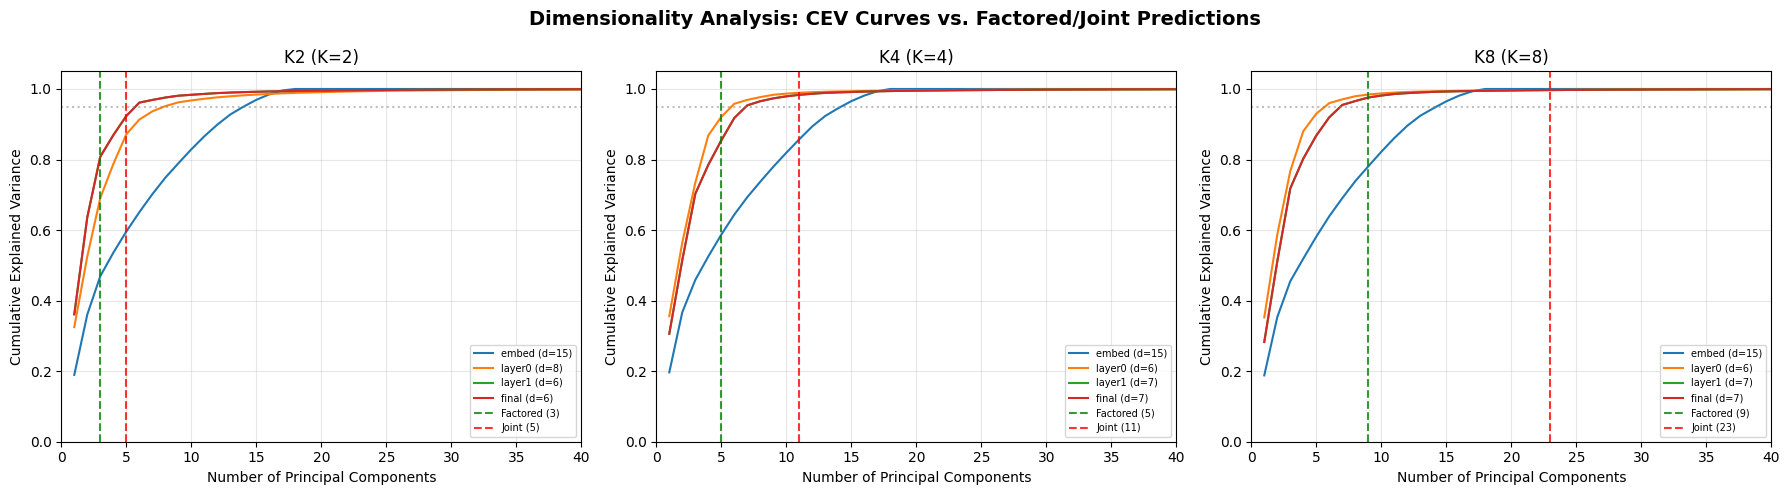


Effective dimensionality at 95% CEV:
Experiment   Prediction |   |   |   | e | m | b | e | d |   |   |   | l | a | y | e | r | 0 |   |   |   | l | a | y | e | r | 1 |   |   |   |   | f | i | n | a | l
K2                K+1=3 |       15 |        8 |        6 |        6 | 
K4                K+1=5 |       15 |        6 |        7 |        7 | 
K8                K+1=9 |       15 |        6 |        7 |        7 | 

Saved: fig_cev_curves.pdf


In [8]:
# ============================================================
# ANALYSIS B: DIMENSIONALITY (PCA / CEV)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

dim_summary = {}

for idx, (exp_name, res) in enumerate(all_results.items()):
    ax = axes[idx]
    K = res["K"]
    seed_data = res["seeds"][0]
    acts = seed_data["activations"]

    layer_dims = {}
    for layer_name in ["embed", "layer0", "layer1", "final"]:
        if layer_name not in acts:
            continue
        # Flatten across all positions for overall dimensionality
        acts_flat = acts[layer_name].reshape(-1, D_MODEL).numpy()
        pca = PCA()
        pca.fit(acts_flat)
        cev = np.cumsum(pca.explained_variance_ratio_)
        eff_dim = np.searchsorted(cev, 0.95) + 1

        ax.plot(range(1, len(cev)+1), cev, label=f"{layer_name} (d={eff_dim})", linewidth=1.5)
        layer_dims[layer_name] = eff_dim

    # Prediction lines
    factored_dim = K + 1
    joint_dim = 3 * K - 1
    ax.axvline(factored_dim, color="green", linestyle="--", alpha=0.8, label=f"Factored ({factored_dim})")
    ax.axvline(joint_dim, color="red", linestyle="--", alpha=0.8, label=f"Joint ({joint_dim})")
    ax.axhline(0.95, color="gray", linestyle=":", alpha=0.5)

    ax.set_title(f"{exp_name} (K={K})")
    ax.set_xlabel("Number of Principal Components")
    ax.set_ylabel("Cumulative Explained Variance")
    ax.legend(fontsize=7, loc="lower right")
    ax.set_xlim(0, min(40, D_MODEL))
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

    dim_summary[exp_name] = layer_dims

plt.suptitle("Dimensionality Analysis: CEV Curves vs. Factored/Joint Predictions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_cev_curves.pdf", dpi=150, bbox_inches="tight")
plt.show()

print("\nEffective dimensionality at 95% CEV:")
print(f"{'Experiment':<10} {'Prediction':>12} | ", end="")
print(" | ".join(f"{'embed':>8} {'layer0':>8} {'layer1':>8} {'final':>8}"))
for exp_name, dims in dim_summary.items():
    K = all_results[exp_name]["K"]
    print(f"{exp_name:<10} {'K+1='+str(K+1):>12} | ", end="")
    for layer in ["embed", "layer0", "layer1", "final"]:
        print(f"{dims.get(layer, '-'):>8}", end=" | ")
    print()
print("\nSaved: fig_cev_curves.pdf")

## 8. Analysis C — Belief Geometry Recovery

Fit linear regression from residual stream activations to ground-truth belief vectors. Visualize recovered geometry vs. theoretical simplex.


--- K2: Belief Geometry Recovery ---
  Component 0 (p=0.1): RMSE=0.0290, R²=0.9948
  Component 1 (p=0.9): RMSE=0.0104, R²=0.9961


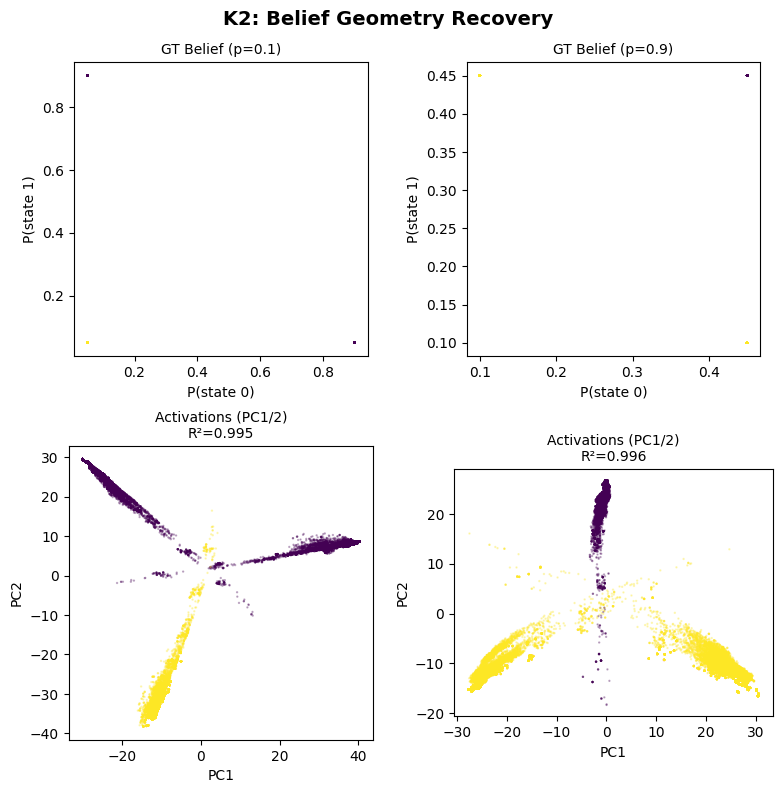

  Saved: fig_belief_geometry_K2.pdf

--- K4: Belief Geometry Recovery ---
  Component 0 (p=0.1): RMSE=0.0552, R²=0.9811
  Component 1 (p=0.3): RMSE=0.0588, R²=0.9488
  Component 2 (p=0.7): RMSE=0.0066, R²=0.9214
  Component 3 (p=0.9): RMSE=0.0442, R²=0.9279


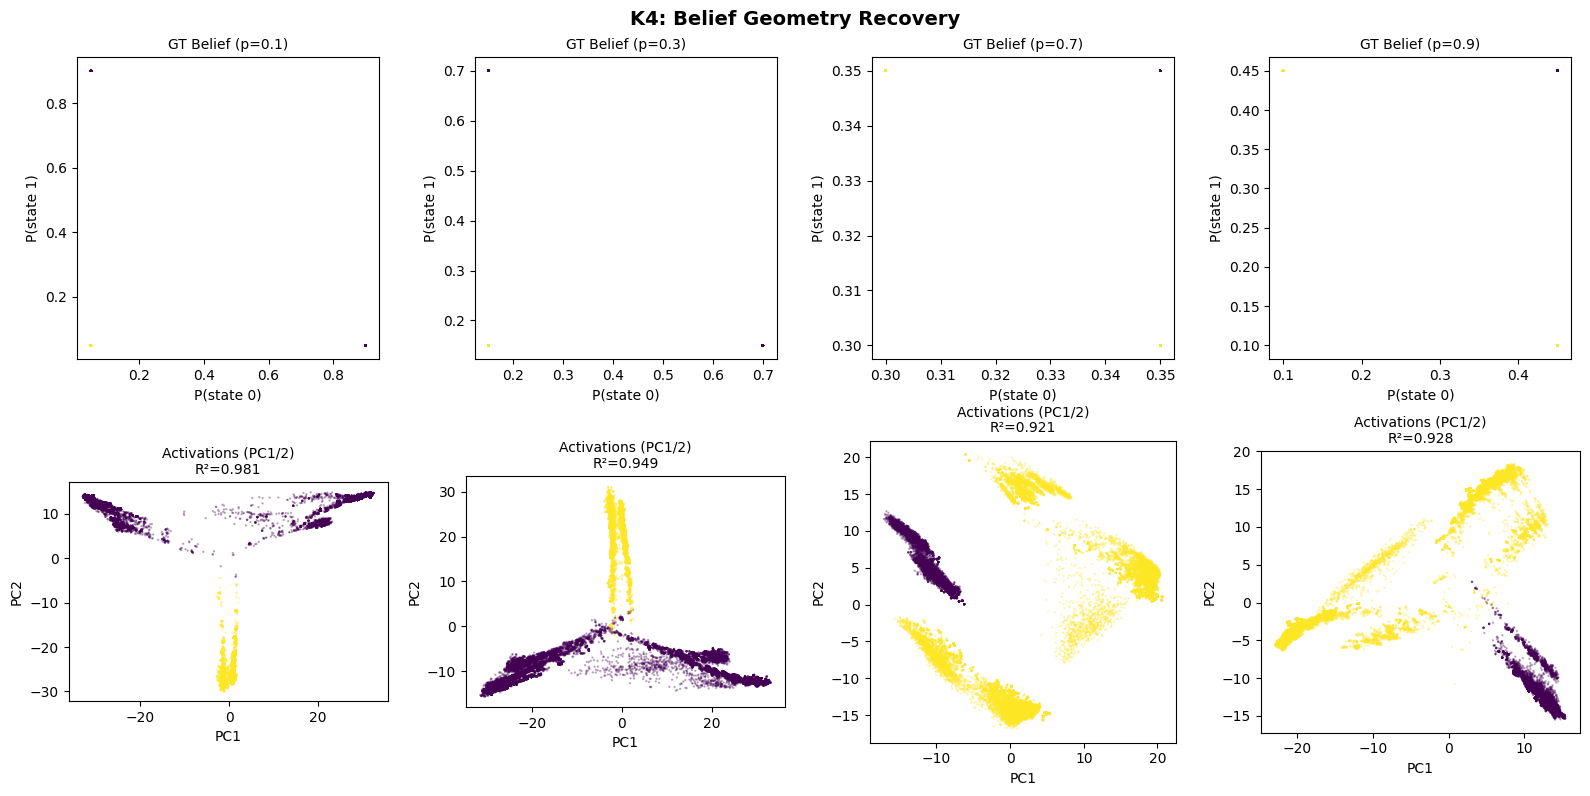

  Saved: fig_belief_geometry_K4.pdf

--- K8: Belief Geometry Recovery ---
  Component 0 (p=0.1): RMSE=0.0204, R²=0.9974
  Component 1 (p=0.2): RMSE=0.0189, R²=0.9967
  Component 2 (p=0.3): RMSE=0.0160, R²=0.9962
  Component 3 (p=0.4): RMSE=0.0127, R²=0.9955


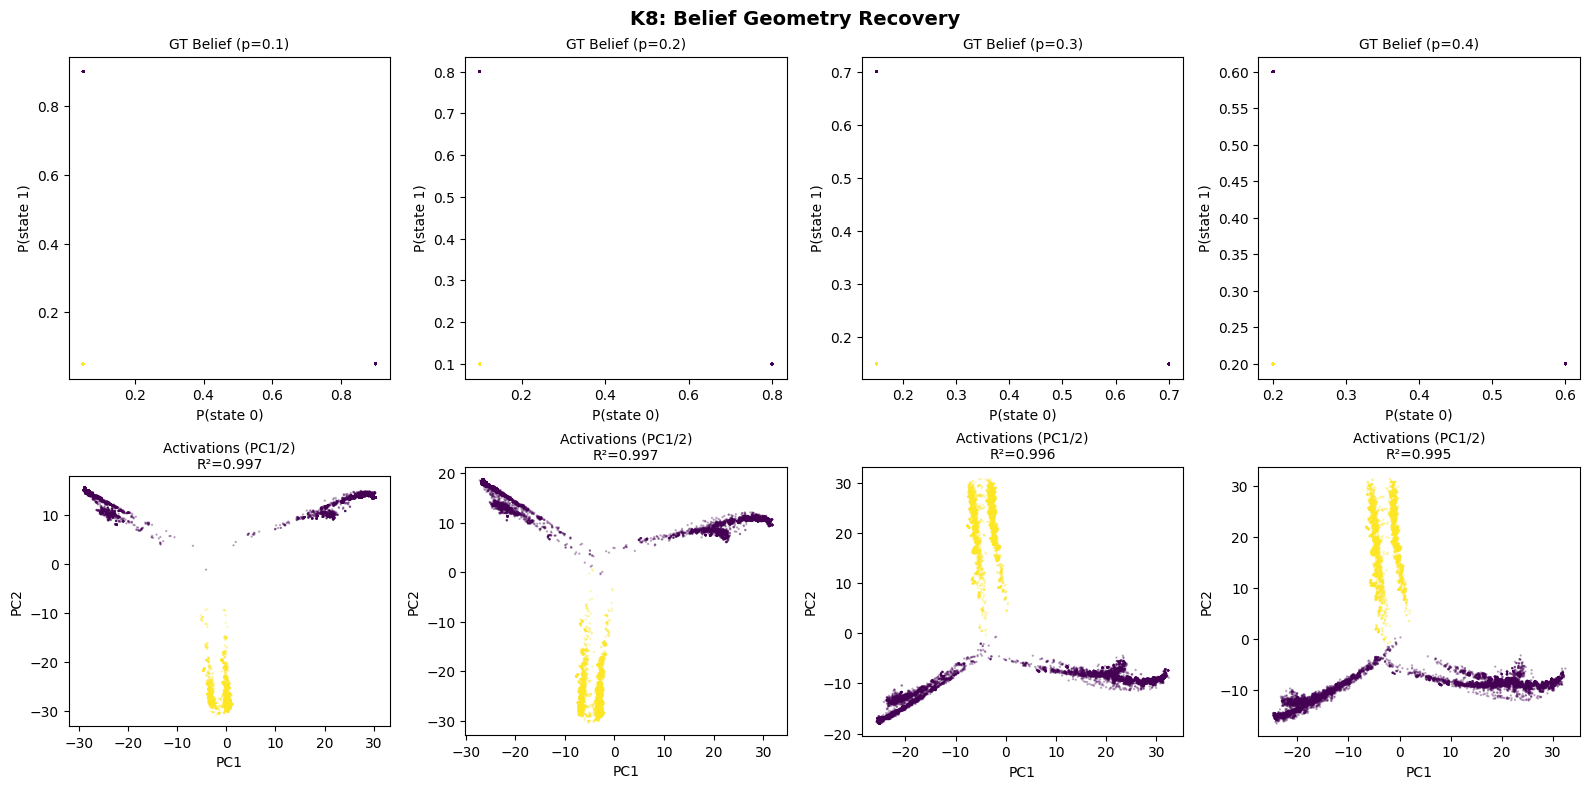

  Saved: fig_belief_geometry_K8.pdf


In [9]:
# ============================================================
# ANALYSIS C: BELIEF GEOMETRY RECOVERY
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA

for exp_name, res in all_results.items():
    K = res["K"]
    p_values = res["p_values"]
    seed_data = res["seeds"][0]
    final_acts = seed_data["activations"]["final"]  # (N, seq_len, d_model)
    beliefs = seed_data["beliefs"]                   # (N, seq_len, K, 3)
    comp_ids = seed_data["test_comp_ids"]

    n_cols = min(K, 4)
    fig, axes = plt.subplots(2, n_cols, figsize=(4*n_cols, 8))
    if n_cols == 1:
        axes = axes.reshape(2, 1)

    print(f"\n--- {exp_name}: Belief Geometry Recovery ---")

    for ki in range(min(K, n_cols)):
        mask = comp_ids == ki
        if mask.sum() < 100:
            continue

        # Use positions 4+ (enough context to have varied beliefs)
        pos_range = range(4, SEQ_LEN + 1)
        acts_list, beliefs_list = [], []
        for t in pos_range:
            acts_list.append(final_acts[mask, t, :])
            beliefs_list.append(beliefs[mask, t, ki, :])
        acts_k = torch.cat(acts_list, dim=0).numpy()
        beliefs_k = torch.cat(beliefs_list, dim=0).numpy()

        # Fit linear probe with dynamic split (80% train, 20% test)
        n_samples = acts_k.shape[0]
        n_train = int(n_samples * 0.8)

        if n_train == 0:
            print(f"  Skipping component {ki} (insufficient data)")
            continue

        reg = Ridge(alpha=1.0)
        reg.fit(acts_k[:n_train], beliefs_k[:n_train])
        pred = reg.predict(acts_k[n_train:])
        gt = beliefs_k[n_train:]
        rmse = np.sqrt(((pred - gt)**2).mean())
        r2 = reg.score(acts_k[n_train:], gt)
        print(f"  Component {ki} (p={p_values[ki]:.1f}): RMSE={rmse:.4f}, R²={r2:.4f}")

        # PCA on activations for this component
        pca_k = PCA(n_components=2)
        proj = pca_k.fit_transform(acts_k)

        # Plot ground truth
        ax = axes[0, ki]
        sc = ax.scatter(beliefs_k[:, 0], beliefs_k[:, 1], c=beliefs_k[:, 2],
                        cmap="viridis", s=0.5, alpha=0.3)
        ax.set_title(f"GT Belief (p={p_values[ki]:.1f})", fontsize=10)
        ax.set_xlabel("P(state 0)")
        ax.set_ylabel("P(state 1)")
        ax.set_aspect("equal")

        # Plot projected activations
        ax = axes[1, ki]
        sc = ax.scatter(proj[:, 0], proj[:, 1], c=beliefs_k[:, 2],
                        cmap="viridis", s=0.5, alpha=0.3)
        ax.set_title(f"Activations (PC1/2)\nR²={r2:.3f}", fontsize=10)
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_aspect("equal")

    plt.suptitle(f"{exp_name}: Belief Geometry Recovery", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"fig_belief_geometry_{exp_name}.pdf", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: fig_belief_geometry_{exp_name}.pdf")

## 9. Analysis D — Component Identification vs. Context Position

**Prediction:** Linear probe accuracy for component identity should increase sigmoidally with context position, reaching near-perfect by position 8+.

K2: Probe acc at pos 1=0.495, pos 8=0.999, pos 16=1.000
K4: Probe acc at pos 1=0.252, pos 8=0.716, pos 16=0.818
K8: Probe acc at pos 1=0.132, pos 8=0.353, pos 16=0.469


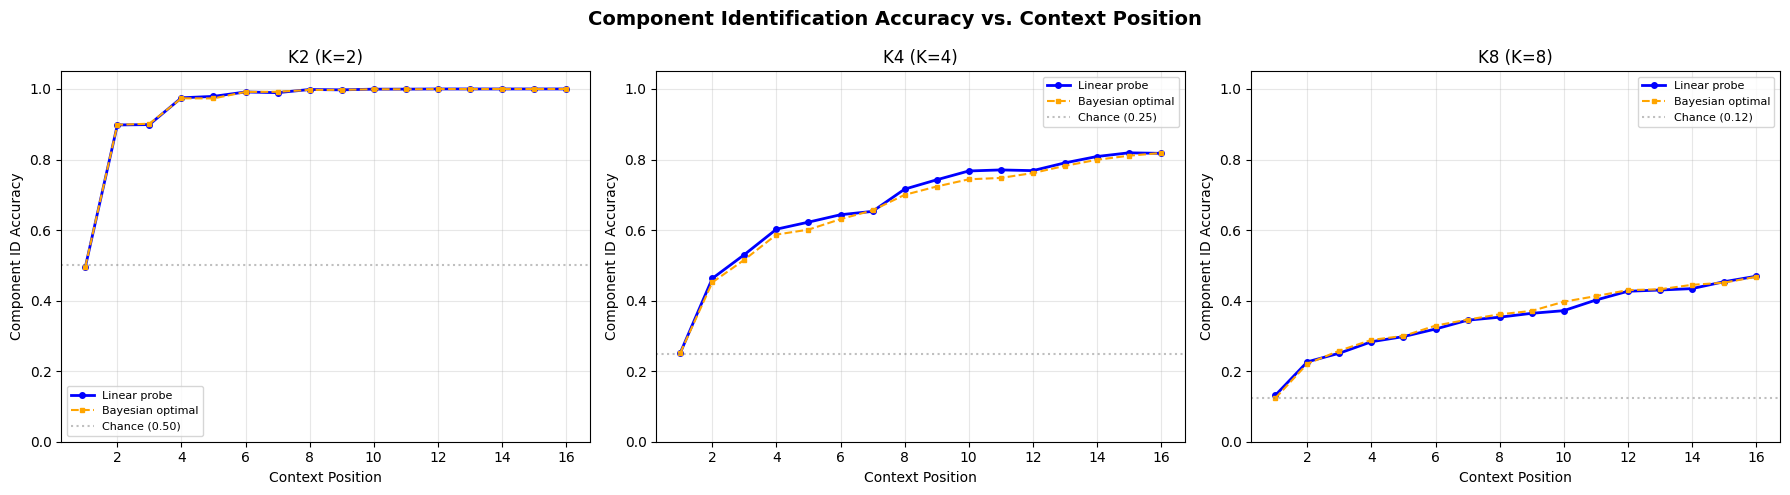


Saved: fig_component_id_vs_position.pdf


In [10]:
# ============================================================
# ANALYSIS D: COMPONENT ID ACCURACY vs. CONTEXT POSITION
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (exp_name, res) in enumerate(all_results.items()):
    ax = axes[idx]
    K = res["K"]
    seed_data = res["seeds"][0]
    final_acts = seed_data["activations"]["final"]
    comp_ids = seed_data["test_comp_ids"].numpy()
    comp_post = seed_data["comp_posterior"]  # (N, seq_len, K)

    positions = list(range(1, SEQ_LEN + 1))  # Skip BOS at 0
    probe_accs = []
    bayesian_accs = []

    # Dynamic split size
    n_samples = len(comp_ids)
    n_train = int(n_samples * 0.8)

    for t in positions:
        # Linear probe
        acts_t = final_acts[:, t, :].numpy()
        clf = LogisticRegression(max_iter=1000, random_state=0, C=1.0)
        clf.fit(acts_t[:n_train], comp_ids[:n_train])
        acc = accuracy_score(comp_ids[n_train:], clf.predict(acts_t[n_train:]))
        probe_accs.append(acc)

        # Bayesian optimal (argmax of posterior)
        bay_pred = comp_post[:, t, :].argmax(dim=1).numpy()
        bay_acc = accuracy_score(comp_ids, bay_pred)
        bayesian_accs.append(bay_acc)

    ax.plot(positions, probe_accs, "o-", linewidth=2, markersize=4, label="Linear probe", color="blue")
    ax.plot(positions, bayesian_accs, "s--", linewidth=1.5, markersize=3, label="Bayesian optimal", color="orange")
    ax.axhline(1.0/K, color="gray", linestyle=":", alpha=0.5, label=f"Chance ({1/K:.2f})")
    ax.set_title(f"{exp_name} (K={K})")
    ax.set_xlabel("Context Position")
    ax.set_ylabel("Component ID Accuracy")
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

    print(f"{exp_name}: Probe acc at pos 1={probe_accs[0]:.3f}, pos 8={probe_accs[7]:.3f}, pos 16={probe_accs[-1]:.3f}")

plt.suptitle("Component Identification Accuracy vs. Context Position", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_component_id_vs_position.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: fig_component_id_vs_position.pdf")

## 10. Analysis E — Orthogonality of Factor Subspaces (Vary-One)

Identify the component-identity subspace and within-component belief subspace via vary-one PCA, then measure their overlap.

In [21]:
# ============================================================
# ANALYSIS E: ORTHOGONALITY — VARY-ONE SUBSPACE ANALYSIS
# ============================================================
import numpy as np
import torch
from sklearn.decomposition import PCA

def subspace_overlap(A, B):
    """Normalized overlap between orthonormal bases A and B (columns)."""
    A_orth, _ = np.linalg.qr(A)
    B_orth, _ = np.linalg.qr(B)
    product = A_orth.T @ B_orth
    return (product ** 2).sum() / min(A.shape[1], B.shape[1])

print("Subspace Orthogonality Analysis\n")

for exp_name, res in all_results.items():
    K = res["K"]
    seed_data = res["seeds"][0]
    final_acts = seed_data["activations"]["final"]  # (N, seq_len, d_model)
    comp_ids = seed_data["test_comp_ids"].numpy()

    # Use late positions (8+) where component identity is clear
    late_acts = final_acts[:, 8:, :].reshape(N_TEST, -1, D_MODEL)  # (N, late_pos, d)

    # --- Component-identity subspace ---
    # Mean activation per sample (average over positions), then PCA across samples
    mean_acts = late_acts.mean(dim=1).numpy()  # (N, d_model)
    # Variation driven by component identity
    comp_centered = []
    for ki in range(K):
        mask = comp_ids == ki
        comp_centered.append(mean_acts[mask].mean(axis=0))
    comp_means = np.array(comp_centered)  # (K, d_model)
    comp_means -= comp_means.mean(axis=0)
    pca_comp = PCA(n_components=min(K-1, D_MODEL))
    pca_comp.fit(comp_means)
    comp_subspace = pca_comp.components_.T  # (d_model, K-1)

    # --- Within-component belief subspace ---
    # For each component, collect activations, mean-center, PCA
    all_within = []
    for ki in range(K):
        mask = comp_ids == ki
        acts_k = late_acts[mask].reshape(-1, D_MODEL).numpy()
        acts_k -= acts_k.mean(axis=0)
        all_within.append(acts_k)
    within_all = np.concatenate(all_within, axis=0)
    pca_within = PCA(n_components=2)
    pca_within.fit(within_all)
    belief_subspace = pca_within.components_.T  # (d_model, 2)

    # Compute overlap
    overlap = subspace_overlap(comp_subspace, belief_subspace)
    print(f"{exp_name} (K={K}):")
    print(f"  Component-ID subspace dim: {comp_subspace.shape[1]}")
    print(f"  Belief subspace dim: {belief_subspace.shape[1]}")
    print(f"  Subspace overlap: {overlap:.4f}  (0=orthogonal, 1=identical)")
    print(f"  Prediction: overlap ≈ 0 (orthogonal)")
    print()

Subspace Orthogonality Analysis

K2 (K=2):
  Component-ID subspace dim: 1
  Belief subspace dim: 2
  Subspace overlap: 0.0112  (0=orthogonal, 1=identical)
  Prediction: overlap ≈ 0 (orthogonal)

K4 (K=4):
  Component-ID subspace dim: 3
  Belief subspace dim: 2
  Subspace overlap: 0.0654  (0=orthogonal, 1=identical)
  Prediction: overlap ≈ 0 (orthogonal)

K8 (K=8):
  Component-ID subspace dim: 7
  Belief subspace dim: 2
  Subspace overlap: 0.9335  (0=orthogonal, 1=identical)
  Prediction: overlap ≈ 0 (orthogonal)



## 11. Analysis F (Additional) — Training Dynamics: Factorization Phase Transitions

Track effective dimensionality at each checkpoint to see whether the model finds the factored solution early and dwells there.


--- K2: Training Dynamics ---
Moving model to device:  cuda
Moving model to device:  cuda
  Step 0: eff_dim = 21
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
  Step 2000: eff_dim = 7
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
  Step 4000: eff_dim = 6
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
  Step 6000: eff_dim = 6
Moving model to device:  cuda
Moving model to device:  cuda
Moving model to device:  cuda
M

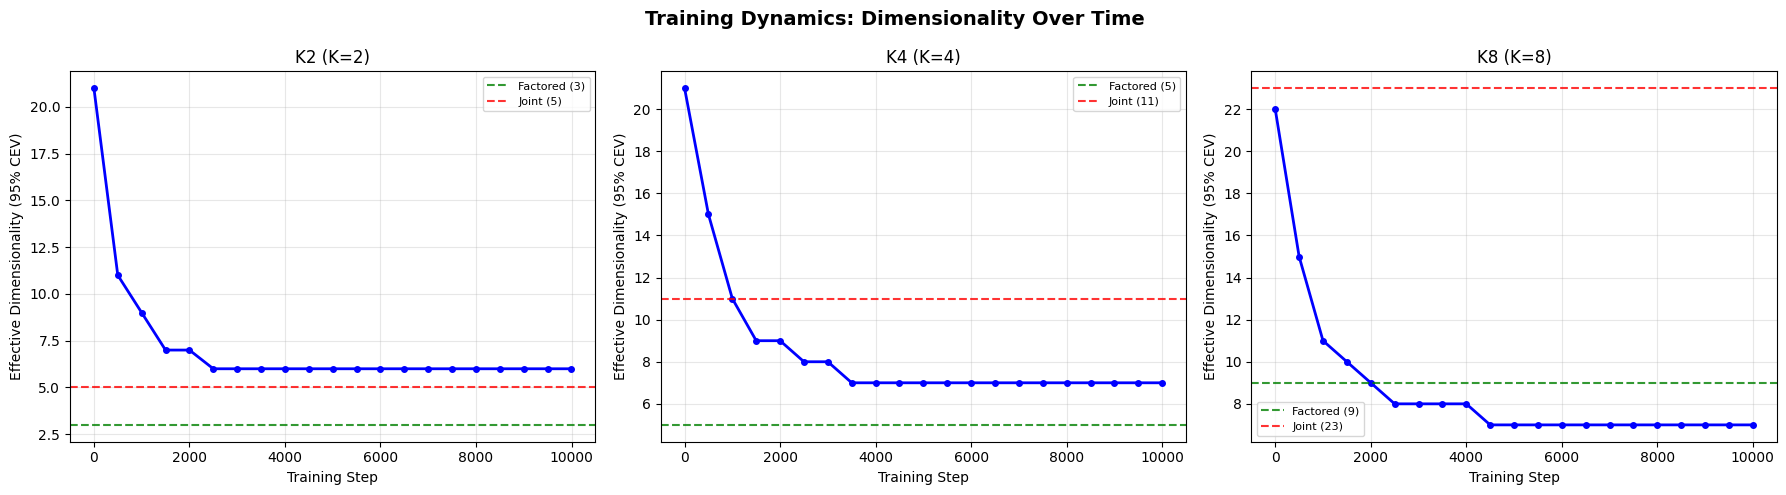


Saved: fig_training_dynamics.pdf


In [12]:
# ============================================================
# ANALYSIS F: TRAINING DYNAMICS — DIMENSIONALITY OVER TIME
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (exp_name, res) in enumerate(all_results.items()):
    ax = axes[idx]
    K = res["K"]
    p_values = res["p_values"]
    seed_data = res["seeds"][0]
    checkpoints = seed_data["checkpoints"]

    # Fixed test data for consistency
    torch.manual_seed(999)
    np.random.seed(999)
    dataset = NonErgodicDataset(p_values=p_values, seq_len=SEQ_LEN)
    test_tokens, _ = dataset.sample_batch(3000)

    steps_list = sorted(checkpoints.keys())
    dims_list = []

    print(f"\n--- {exp_name}: Training Dynamics ---")
    for step in steps_list:
        model = create_model(
            n_layers=N_LAYERS, d_model=D_MODEL, d_mlp=D_MLP,
            n_heads=N_HEADS, n_ctx=SEQ_LEN + 1, d_vocab=4, device=DEVICE,
        )
        model.load_state_dict(checkpoints[step])
        model.to(DEVICE)

        acts = extract_activations(model, test_tokens.to(DEVICE))
        acts_flat = acts["final"].cpu().reshape(-1, D_MODEL).numpy()
        pca = PCA()
        pca.fit(acts_flat)
        cev = np.cumsum(pca.explained_variance_ratio_)
        eff_dim = np.searchsorted(cev, 0.95) + 1
        dims_list.append(eff_dim)

        if step % 2000 == 0 or step == steps_list[-1]:
            print(f"  Step {step}: eff_dim = {eff_dim}")

        del model
        torch.cuda.empty_cache() if DEVICE == "cuda" else None

    ax.plot(steps_list, dims_list, "o-", linewidth=2, markersize=4, color="blue")
    ax.axhline(K+1, color="green", linestyle="--", alpha=0.8, label=f"Factored ({K+1})")
    ax.axhline(3*K-1, color="red", linestyle="--", alpha=0.8, label=f"Joint ({3*K-1})")
    ax.set_title(f"{exp_name} (K={K})")
    ax.set_xlabel("Training Step")
    ax.set_ylabel("Effective Dimensionality (95% CEV)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Training Dynamics: Dimensionality Over Time", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_training_dynamics.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: fig_training_dynamics.pdf")

## 12. Dimensionality Scaling Summary

The key test: does effective dimensionality scale as K+1 (factored) or 3K-1 (joint)?

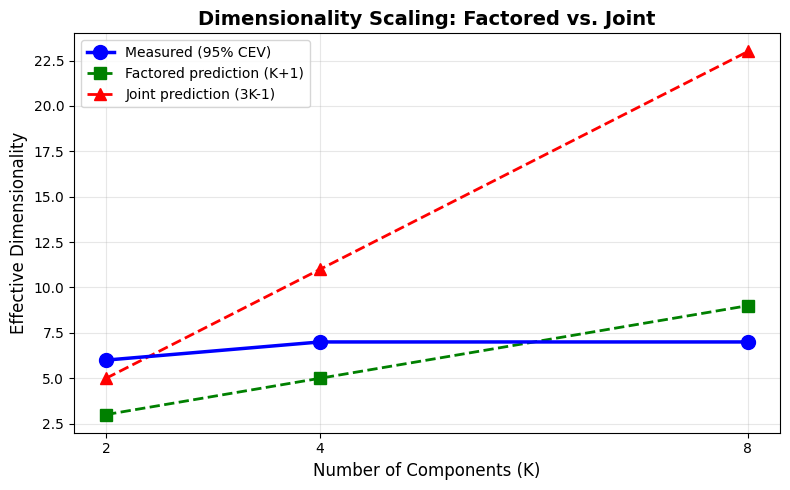


Scaling Summary:
   K   Measured   Factored      Joint
   2          6          3          5
   4          7          5         11
   8          7          9         23

Saved: fig_scaling_summary.pdf


In [13]:
# ============================================================
# SCALING SUMMARY: Effective Dim vs K
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

K_values = []
measured_dims = []  # Average across seeds
factored_pred = []
joint_pred = []

for exp_name, res in all_results.items():
    K = res["K"]
    K_values.append(K)
    factored_pred.append(K + 1)
    joint_pred.append(3 * K - 1)

    # Measure from seed 0 final layer
    seed_data = res["seeds"][0]
    acts_flat = seed_data["activations"]["final"].reshape(-1, D_MODEL).numpy()
    pca = PCA()
    pca.fit(acts_flat)
    cev = np.cumsum(pca.explained_variance_ratio_)
    eff_dim = np.searchsorted(cev, 0.95) + 1
    measured_dims.append(eff_dim)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_values, measured_dims, "o-", linewidth=2.5, markersize=10, label="Measured (95% CEV)", color="blue", zorder=3)
ax.plot(K_values, factored_pred, "s--", linewidth=2, markersize=8, label="Factored prediction (K+1)", color="green")
ax.plot(K_values, joint_pred, "^--", linewidth=2, markersize=8, label="Joint prediction (3K-1)", color="red")
ax.set_xlabel("Number of Components (K)", fontsize=12)
ax.set_ylabel("Effective Dimensionality", fontsize=12)
ax.set_title("Dimensionality Scaling: Factored vs. Joint", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xticks(K_values)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig_scaling_summary.pdf", dpi=150, bbox_inches="tight")
plt.show()

print("\nScaling Summary:")
print(f"{'K':>4} {'Measured':>10} {'Factored':>10} {'Joint':>10}")
for k, m, f, j in zip(K_values, measured_dims, factored_pred, joint_pred):
    print(f"{k:>4} {m:>10} {f:>10} {j:>10}")
print("\nSaved: fig_scaling_summary.pdf")

## 13. Save All Figures and Results to Google Drive (Optional)

Run this cell to save everything to your Google Drive for easy access.

In [14]:
# ============================================================
# SAVE TO GOOGLE DRIVE (optional — uncomment to use)
# ============================================================

# from google.colab import drive
# drive.mount('/content/drive')
# import shutil
# save_dir = "/content/drive/MyDrive/MATS_experiment"
# !mkdir -p {save_dir}
# for f in ["fig_loss_curves.pdf", "fig_cev_curves.pdf", "fig_component_id_vs_position.pdf",
#           "fig_training_dynamics.pdf", "fig_scaling_summary.pdf"]:
#     if os.path.exists(f):
#         shutil.copy(f, save_dir)
# for f in glob.glob("fig_belief_geometry_*.pdf"):
#     shutil.copy(f, save_dir)
# print(f"All figures saved to {save_dir}")

# List all generated figures
import glob
pdfs = glob.glob("*.pdf")
print(f"Generated {len(pdfs)} figure files:")
for f in sorted(pdfs):
    print(f"  {f}")

print("\n=== EXPERIMENT COMPLETE ===")
print("Download the PDF figures above for your writeup.")
print("Key figures:")
print("  fig_scaling_summary.pdf     — Main result: dimensionality vs K")
print("  fig_cev_curves.pdf          — CEV curves with factored/joint predictions")
print("  fig_component_id_vs_position.pdf — Component identification over context")
print("  fig_training_dynamics.pdf   — How dimensionality evolves during training")
print("  fig_belief_geometry_*.pdf   — Recovered belief simplex geometry")
print("  fig_loss_curves.pdf         — Training loss curves")

Generated 10 figure files:
  fig_a1_capacity_cev.pdf
  fig_a1_capacity_scaling.pdf
  fig_belief_geometry_K2.pdf
  fig_belief_geometry_K4.pdf
  fig_belief_geometry_K8.pdf
  fig_cev_curves.pdf
  fig_component_id_vs_position.pdf
  fig_loss_curves.pdf
  fig_scaling_summary.pdf
  fig_training_dynamics.pdf

=== EXPERIMENT COMPLETE ===
Download the PDF figures above for your writeup.
Key figures:
  fig_scaling_summary.pdf     — Main result: dimensionality vs K
  fig_cev_curves.pdf          — CEV curves with factored/joint predictions
  fig_component_id_vs_position.pdf — Component identification over context
  fig_training_dynamics.pdf   — How dimensionality evolves during training
  fig_belief_geometry_*.pdf   — Recovered belief simplex geometry
  fig_loss_curves.pdf         — Training loss curves


## VALIDATION EXPERIMENTS (Experiment 2)

These cells address open questions from the baseline experiment:
- **V1:** Position-specific PCA — is dimensionality inflated by positional encoding?
- **V2:** CEV threshold sensitivity & participation ratio — is d=6-7 a threshold artifact?
- **V3:** Per-component intrinsic dimensionality — is within-component dim ≈ 2?
- **V4:** Orthogonality re-run — are factor subspaces orthogonal?
- **V5:** Late-position dimensionality scaling — cleaner test of K+1 prediction

V1: POSITION-SPECIFIC DIMENSIONALITY

K2 (K=2):
  BOS (pos 0): d = 2
  Early (pos 1-4) avg: d = 4.2
  Late (pos 8-16) avg: d = 4.8
  All-position PCA (original): d = 6-7
  Factored prediction: d = 3

K4 (K=4):
  BOS (pos 0): d = 5
  Early (pos 1-4) avg: d = 4.2
  Late (pos 8-16) avg: d = 6.0
  All-position PCA (original): d = 6-7
  Factored prediction: d = 5

K8 (K=8):
  BOS (pos 0): d = 4
  Early (pos 1-4) avg: d = 4.5
  Late (pos 8-16) avg: d = 6.0
  All-position PCA (original): d = 6-7
  Factored prediction: d = 9


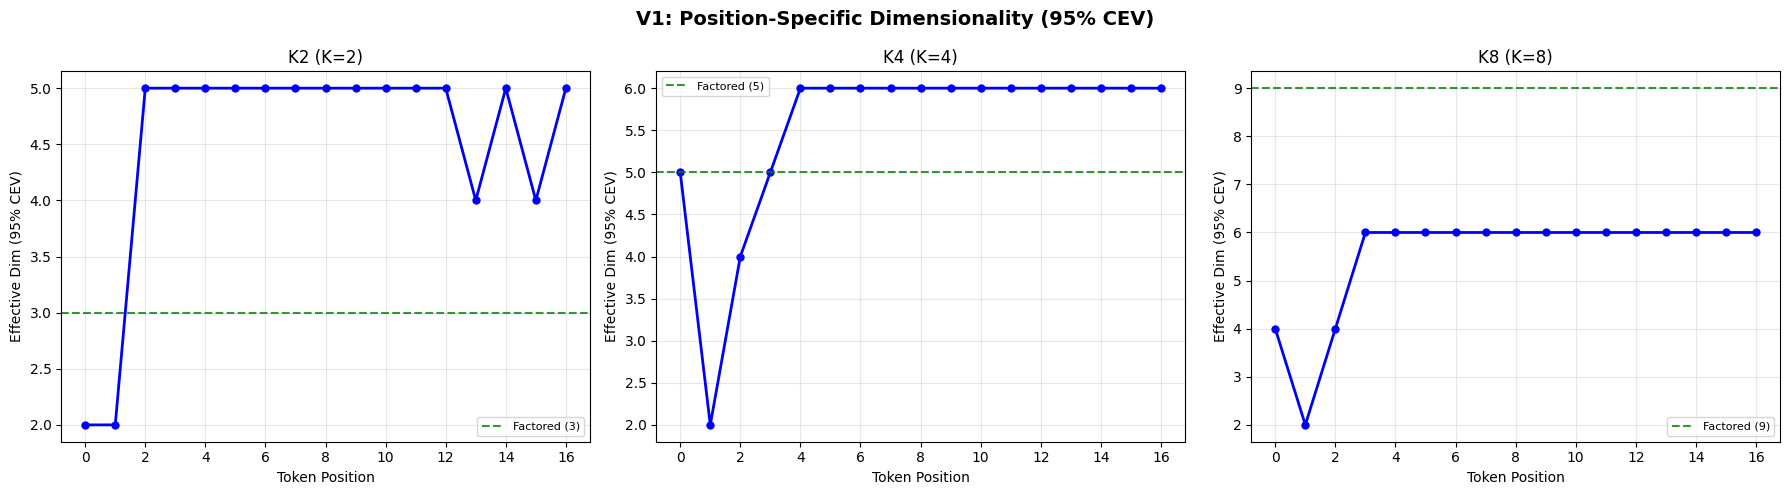


Saved: fig_v1_position_specific_dim.pdf


In [15]:
# ============================================================
# V1: POSITION-SPECIFIC DIMENSIONALITY
# Question: Is the flat d=6-7 inflated by positional encoding variance?
# Method: Compute PCA at each position independently
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

print("=" * 70)
print("V1: POSITION-SPECIFIC DIMENSIONALITY")
print("=" * 70)

pos_dim_results = {}

for idx, (exp_name, res) in enumerate(all_results.items()):
    ax = axes[idx]
    K = res["K"]
    seed_data = res["seeds"][0]
    final_acts = seed_data["activations"]["final"]  # (N, 17, 64)

    pos_dims = []
    for t in range(final_acts.shape[1]):
        acts_t = final_acts[:, t, :].numpy()  # (N, 64)
        pca = PCA()
        pca.fit(acts_t)
        cev = np.cumsum(pca.explained_variance_ratio_)
        eff_dim = np.searchsorted(cev, 0.95) + 1
        pos_dims.append(eff_dim)

    pos_dim_results[exp_name] = pos_dims

    ax.plot(range(final_acts.shape[1]), pos_dims, "o-", linewidth=2, markersize=5, color="blue")
    ax.axhline(K + 1, color="green", linestyle="--", alpha=0.8, label=f"Factored ({K+1})")
    ax.set_title(f"{exp_name} (K={K})")
    ax.set_xlabel("Token Position")
    ax.set_ylabel("Effective Dim (95% CEV)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Print summary
    print(f"\n{exp_name} (K={K}):")
    print(f"  BOS (pos 0): d = {pos_dims[0]}")
    print(f"  Early (pos 1-4) avg: d = {np.mean(pos_dims[1:5]):.1f}")
    print(f"  Late (pos 8-16) avg: d = {np.mean(pos_dims[8:]):.1f}")
    print(f"  All-position PCA (original): d = 6-7")
    print(f"  Factored prediction: d = {K+1}")

plt.suptitle("V1: Position-Specific Dimensionality (95% CEV)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_v1_position_specific_dim.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: fig_v1_position_specific_dim.pdf")

V2: CEV THRESHOLD SENSITIVITY & PARTICIPATION RATIO

Experiment |  CEV 85% |  CEV 90% |  CEV 95% |  CEV 99% | Part.Ratio | Stable Rank
--------------------------------------------------------------------------------
K2 (all)   |        4 |        5 |        6 |       14 |        4.1 |         2.8
K2 (late)  |        3 |        4 |        5 |        8 |        3.3 |         2.3
K4 (all)   |        5 |        6 |        7 |       14 |        5.3 |         3.3
K4 (late)  |        5 |        5 |        6 |       11 |        4.6 |         2.8
K8 (all)   |        5 |        6 |        7 |       13 |        5.2 |         3.5
K8 (late)  |        5 |        5 |        6 |       10 |        4.7 |         3.1

Predictions |   K2: factored=3, joint=5  |    K4: factored=5, joint=11  |    K8: factored=9, joint=23  |  


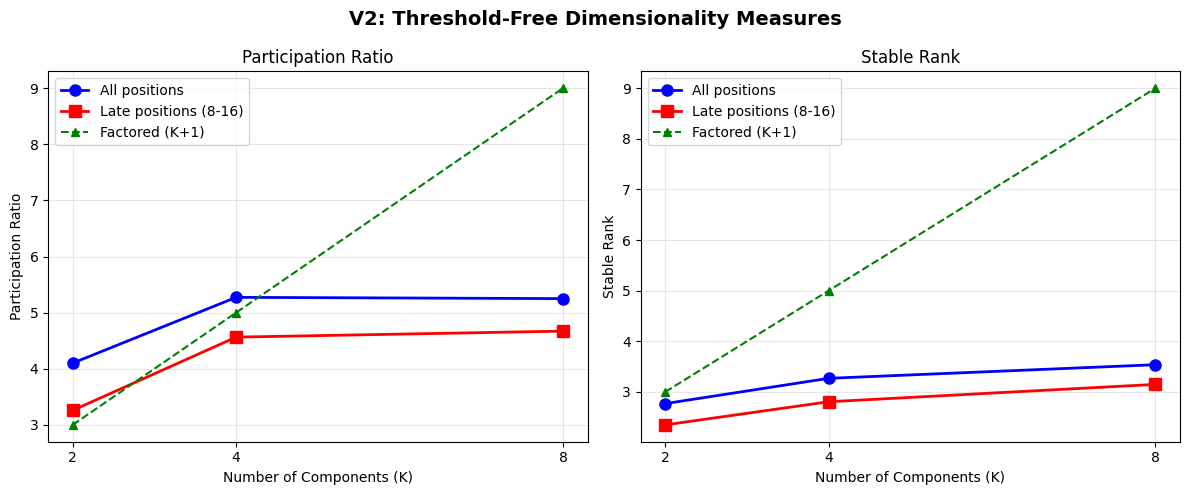


Saved: fig_v2_threshold_sensitivity.pdf


In [16]:
# ============================================================
# V2: CEV THRESHOLD SENSITIVITY & PARTICIPATION RATIO
# Question: Is d=6-7 an artifact of the 95% threshold?
# Method: Test multiple thresholds + threshold-free participation ratio
# ============================================================
import numpy as np
from sklearn.decomposition import PCA

print("=" * 70)
print("V2: CEV THRESHOLD SENSITIVITY & PARTICIPATION RATIO")
print("=" * 70)

thresholds = [0.85, 0.90, 0.95, 0.99]

# Header
print(f"\n{'Experiment':<10} | ", end="")
for th in thresholds:
    print(f"{'CEV '+str(int(th*100))+'%':>8}", end=" | ")
print(f"{'Part.Ratio':>10} | {'Stable Rank':>11}")
print("-" * 80)

v2_results = {}

for exp_name, res in all_results.items():
    K = res["K"]
    seed_data = res["seeds"][0]

    # --- All positions (original method) ---
    acts_flat = seed_data["activations"]["final"].reshape(-1, D_MODEL).numpy()
    pca = PCA()
    pca.fit(acts_flat)
    evals = pca.explained_variance_
    cev = np.cumsum(pca.explained_variance_ratio_)

    dims = {}
    for th in thresholds:
        dims[th] = np.searchsorted(cev, th) + 1

    # Participation ratio: (Σλ)² / Σ(λ²)
    part_ratio = (evals.sum() ** 2) / (evals ** 2).sum()
    # Stable rank: ||A||_F² / ||A||_2²
    stable_rank = evals.sum() / evals[0]

    print(f"{exp_name+' (all)':<10} | ", end="")
    for th in thresholds:
        print(f"{dims[th]:>8}", end=" | ")
    print(f"{part_ratio:>10.1f} | {stable_rank:>11.1f}")

    # --- Late positions only (8-16) ---
    late_acts = seed_data["activations"]["final"][:, 8:, :].reshape(-1, D_MODEL).numpy()
    pca_late = PCA()
    pca_late.fit(late_acts)
    evals_late = pca_late.explained_variance_
    cev_late = np.cumsum(pca_late.explained_variance_ratio_)

    dims_late = {}
    for th in thresholds:
        dims_late[th] = np.searchsorted(cev_late, th) + 1

    part_ratio_late = (evals_late.sum() ** 2) / (evals_late ** 2).sum()
    stable_rank_late = evals_late.sum() / evals_late[0]

    print(f"{exp_name+' (late)':<10} | ", end="")
    for th in thresholds:
        print(f"{dims_late[th]:>8}", end=" | ")
    print(f"{part_ratio_late:>10.1f} | {stable_rank_late:>11.1f}")

    v2_results[exp_name] = {
        "all": {"dims": dims, "part_ratio": part_ratio, "stable_rank": stable_rank},
        "late": {"dims": dims_late, "part_ratio": part_ratio_late, "stable_rank": stable_rank_late},
    }

print(f"\n{'Predictions':<10} | ", end="")
for exp_name in all_results:
    K = all_results[exp_name]["K"]
    print(f"  {exp_name}: factored={K+1}, joint={3*K-1}", end="  |  ")
print()

# Plot: participation ratio and stable rank vs K
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
K_vals = [all_results[e]["K"] for e in all_results]

for i, (metric_name, metric_key) in enumerate([("Participation Ratio", "part_ratio"), ("Stable Rank", "stable_rank")]):
    ax = axes[i]
    vals_all = [v2_results[e]["all"][metric_key] for e in all_results]
    vals_late = [v2_results[e]["late"][metric_key] for e in all_results]
    ax.plot(K_vals, vals_all, "o-", linewidth=2, markersize=8, label="All positions", color="blue")
    ax.plot(K_vals, vals_late, "s-", linewidth=2, markersize=8, label="Late positions (8-16)", color="red")
    ax.plot(K_vals, [k+1 for k in K_vals], "^--", linewidth=1.5, label="Factored (K+1)", color="green")
    ax.set_xlabel("Number of Components (K)")
    ax.set_ylabel(metric_name)
    ax.set_title(metric_name)
    ax.legend()
    ax.set_xticks(K_vals)
    ax.grid(True, alpha=0.3)

plt.suptitle("V2: Threshold-Free Dimensionality Measures", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_v2_threshold_sensitivity.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: fig_v2_threshold_sensitivity.pdf")

V3: PER-COMPONENT INTRINSIC DIMENSIONALITY
Prediction: Within each component, belief lives on 2D simplex → d ≈ 2

K2 (K=2):
  Component 0 (p=0.1): d_95=2, d_90=2, PR=2.1
  Component 1 (p=0.9): d_95=2, d_90=2, PR=2.1
  Average within-component dim: 2.0 (predicted: 2)
K4 (K=4):
  Component 0 (p=0.1): d_95=3, d_90=2, PR=2.2
  Component 1 (p=0.3): d_95=5, d_90=4, PR=2.8
  Component 2 (p=0.7): d_95=7, d_90=5, PR=4.5
  Component 3 (p=0.9): d_95=5, d_90=3, PR=2.8
  Average within-component dim: 5.0 (predicted: 2)
K8 (K=8):
  Component 0 (p=0.1): d_95=4, d_90=2, PR=2.4
  Component 1 (p=0.2): d_95=4, d_90=3, PR=2.7
  Component 2 (p=0.3): d_95=4, d_90=4, PR=3.0
  Component 3 (p=0.4): d_95=6, d_90=4, PR=3.4
  Component 4 (p=0.6): d_95=7, d_90=5, PR=4.3
  Component 5 (p=0.7): d_95=7, d_90=5, PR=4.5
  Component 6 (p=0.8): d_95=7, d_90=5, PR=3.8
  Component 7 (p=0.9): d_95=6, d_90=4, PR=3.0
  Average within-component dim: 5.6 (predicted: 2)


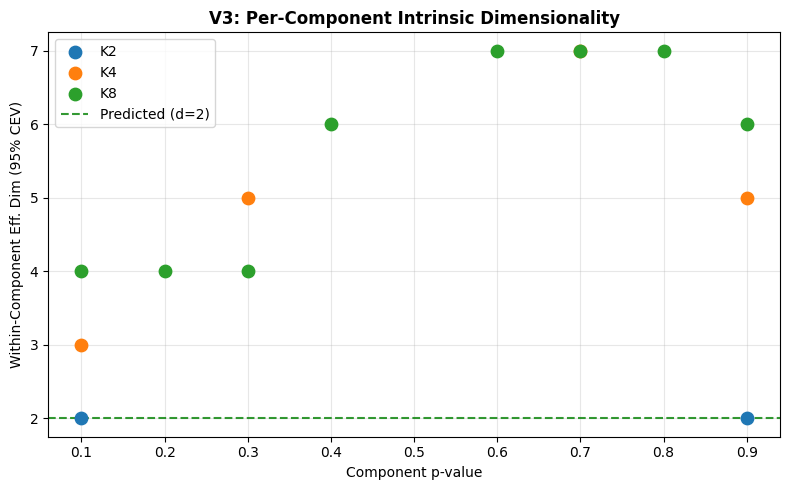


Saved: fig_v3_per_component_dim.pdf


In [17]:
# ============================================================
# V3: PER-COMPONENT INTRINSIC DIMENSIONALITY
# Question: Is within-component dim ≈ 2 (belief simplex)?
# Method: PCA within each component separately, late positions
# ============================================================
import numpy as np
from sklearn.decomposition import PCA

print("=" * 70)
print("V3: PER-COMPONENT INTRINSIC DIMENSIONALITY")
print("=" * 70)
print("Prediction: Within each component, belief lives on 2D simplex → d ≈ 2\n")

v3_results = {}

for exp_name, res in all_results.items():
    K = res["K"]
    seed_data = res["seeds"][0]
    final_acts = seed_data["activations"]["final"]  # (N, 17, 64)
    comp_ids = seed_data["test_comp_ids"].numpy()

    print(f"{exp_name} (K={K}):")
    comp_dims = []

    for ki in range(K):
        mask = comp_ids == ki
        # Late positions only (8-16) for clean signal
        acts_k = final_acts[mask][:, 8:, :].reshape(-1, D_MODEL).numpy()
        pca = PCA()
        pca.fit(acts_k)
        cev = np.cumsum(pca.explained_variance_ratio_)
        eff_dim_95 = np.searchsorted(cev, 0.95) + 1
        eff_dim_90 = np.searchsorted(cev, 0.90) + 1
        evals = pca.explained_variance_
        part_ratio = (evals.sum() ** 2) / (evals ** 2).sum()
        comp_dims.append(eff_dim_95)
        print(f"  Component {ki} (p={res['p_values'][ki]:.1f}): "
              f"d_95={eff_dim_95}, d_90={eff_dim_90}, PR={part_ratio:.1f}")

    avg_dim = np.mean(comp_dims)
    print(f"  Average within-component dim: {avg_dim:.1f} (predicted: 2)")
    v3_results[exp_name] = comp_dims

# Summary plot
fig, ax = plt.subplots(figsize=(8, 5))
for exp_name, dims in v3_results.items():
    K = all_results[exp_name]["K"]
    p_vals = all_results[exp_name]["p_values"]
    ax.scatter(p_vals, dims, s=80, label=exp_name, zorder=3)
ax.axhline(2, color="green", linestyle="--", alpha=0.8, label="Predicted (d=2)")
ax.set_xlabel("Component p-value")
ax.set_ylabel("Within-Component Eff. Dim (95% CEV)")
ax.set_title("V3: Per-Component Intrinsic Dimensionality", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig_v3_per_component_dim.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: fig_v3_per_component_dim.pdf")

In [18]:
# ============================================================
# V4: ORTHOGONALITY RE-RUN (with output capture)
# Question: Are component-identity and belief subspaces orthogonal?
# Method: Vary-one subspace analysis with multiple metrics
# ============================================================
import numpy as np
from sklearn.decomposition import PCA

print("=" * 70)
print("V4: ORTHOGONALITY OF FACTOR SUBSPACES")
print("=" * 70)

def subspace_overlap(A, B):
    """Normalized overlap: 0=orthogonal, 1=identical."""
    A_orth, _ = np.linalg.qr(A)
    B_orth, _ = np.linalg.qr(B)
    product = A_orth.T @ B_orth
    return (product ** 2).sum() / min(A.shape[1], B.shape[1])

def principal_angles(A, B):
    """Compute principal angles between subspaces."""
    A_orth, _ = np.linalg.qr(A)
    B_orth, _ = np.linalg.qr(B)
    _, sigmas, _ = np.linalg.svd(A_orth.T @ B_orth)
    sigmas = np.clip(sigmas, 0, 1)
    return np.arccos(sigmas)

v4_results = {}

for exp_name, res in all_results.items():
    K = res["K"]
    seed_data = res["seeds"][0]
    final_acts = seed_data["activations"]["final"]  # (N, 17, 64)
    comp_ids = seed_data["test_comp_ids"].numpy()

    # Use late positions (8-16) for clean component separation
    late_acts = final_acts[:, 8:, :].reshape(N_TEST, -1, D_MODEL)

    # --- Component-identity subspace ---
    # Compute mean activation per sample (average over late positions)
    mean_acts = late_acts.mean(dim=1).numpy()  # (N, d_model)
    # Get component centroids
    comp_means = np.array([mean_acts[comp_ids == ki].mean(axis=0) for ki in range(K)])
    comp_means -= comp_means.mean(axis=0)
    n_comp_dims = min(K - 1, D_MODEL)
    pca_comp = PCA(n_components=n_comp_dims)
    pca_comp.fit(comp_means)
    comp_subspace = pca_comp.components_.T  # (d_model, n_comp_dims)

    # --- Within-component belief subspace ---
    # Pool within-component residuals across all components
    all_within = []
    for ki in range(K):
        mask = comp_ids == ki
        acts_k = late_acts[mask].reshape(-1, D_MODEL).numpy()
        acts_k -= acts_k.mean(axis=0)  # Remove component mean
        all_within.append(acts_k)
    within_all = np.concatenate(all_within, axis=0)
    pca_within = PCA(n_components=2)
    pca_within.fit(within_all)
    belief_subspace = pca_within.components_.T  # (d_model, 2)

    # Compute metrics
    overlap = subspace_overlap(comp_subspace, belief_subspace)
    angles = principal_angles(comp_subspace, belief_subspace)
    angles_deg = np.degrees(angles)

    print(f"\n{exp_name} (K={K}):")
    print(f"  Component-ID subspace dims: {comp_subspace.shape[1]}")
    print(f"  Belief subspace dims: {belief_subspace.shape[1]}")
    print(f"  Subspace overlap: {overlap:.4f}  (0=orthogonal, 1=identical)")
    print(f"  Principal angles: {', '.join(f'{a:.1f}°' for a in angles_deg)}")
    print(f"  Min principal angle: {angles_deg.min():.1f}°  (90° = perfectly orthogonal)")
    print(f"  Prediction: overlap ≈ 0, angles ≈ 90°")

    v4_results[exp_name] = {
        "overlap": overlap,
        "angles_deg": angles_deg,
        "comp_dims": comp_subspace.shape[1],
        "belief_dims": belief_subspace.shape[1],
    }

# Summary
print("\n\nSUMMARY:")
print(f"{'Experiment':<10} {'Overlap':>10} {'Min Angle':>12} {'Verdict':>20}")
print("-" * 55)
for exp_name, r in v4_results.items():
    verdict = "ORTHOGONAL" if r["overlap"] < 0.1 else ("PARTIAL" if r["overlap"] < 0.3 else "NOT ORTHOGONAL")
    print(f"{exp_name:<10} {r['overlap']:>10.4f} {r['angles_deg'].min():>10.1f}° {verdict:>20}")

V4: ORTHOGONALITY OF FACTOR SUBSPACES

K2 (K=2):
  Component-ID subspace dims: 1
  Belief subspace dims: 2
  Subspace overlap: 0.0112  (0=orthogonal, 1=identical)
  Principal angles: 83.9°
  Min principal angle: 83.9°  (90° = perfectly orthogonal)
  Prediction: overlap ≈ 0, angles ≈ 90°

K4 (K=4):
  Component-ID subspace dims: 3
  Belief subspace dims: 2
  Subspace overlap: 0.0654  (0=orthogonal, 1=identical)
  Principal angles: 69.7°, 84.1°
  Min principal angle: 69.7°  (90° = perfectly orthogonal)
  Prediction: overlap ≈ 0, angles ≈ 90°

K8 (K=8):
  Component-ID subspace dims: 7
  Belief subspace dims: 2
  Subspace overlap: 0.9335  (0=orthogonal, 1=identical)
  Principal angles: 8.2°, 19.6°
  Min principal angle: 8.2°  (90° = perfectly orthogonal)
  Prediction: overlap ≈ 0, angles ≈ 90°


SUMMARY:
Experiment    Overlap    Min Angle              Verdict
-------------------------------------------------------
K2             0.0112       83.9°           ORTHOGONAL
K4             0.0654 

V5: LATE-POSITION DIMENSIONALITY SCALING

   K    pos=4    pos=8   pos=12   pos=16  late-pool   factored    joint
---------------------------------------------------------------------------
   2        5        5        5        5          5          3        5
   4        6        6        6        6          6          5       11
   8        6        6        6        6          6          9       23


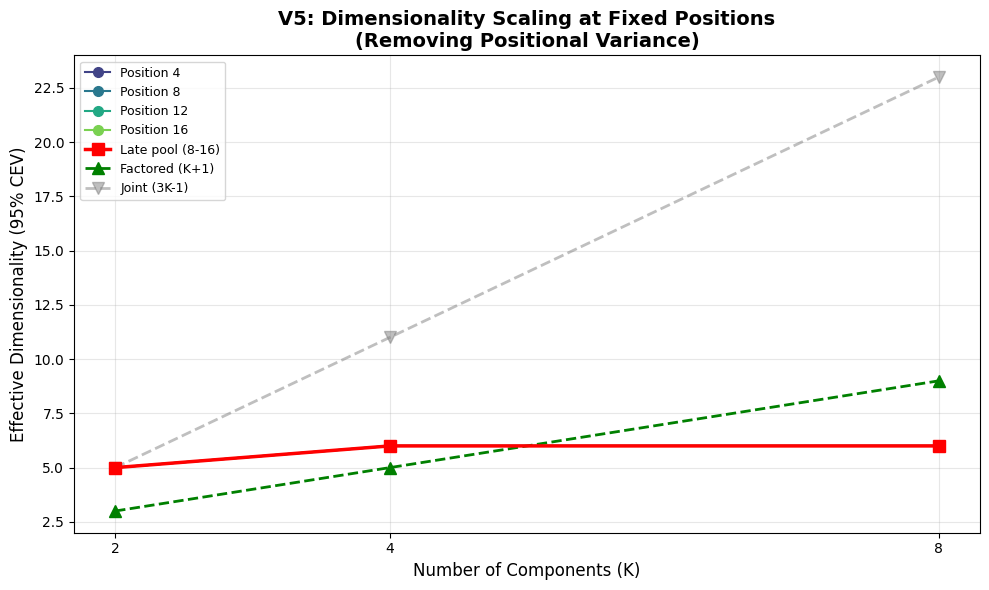


Saved: fig_v5_late_position_scaling.pdf

--- KEY INTERPRETATION ---
If position-specific dims are LOWER than all-position dims (6-7),
it means positional encoding was inflating the original measurement.
If position-specific dims SCALE with K, it supports the K+1 prediction.
If they remain flat, the flat dimensionality is a true property of the representation.


In [19]:
# ============================================================
# V5: LATE-POSITION DIMENSIONALITY SCALING (cleanest test of K+1)
# Question: When we remove positional variance, does d scale as K+1?
# Method: PCA at a single late position (pos=12) across experiments
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

print("=" * 70)
print("V5: LATE-POSITION DIMENSIONALITY SCALING")
print("=" * 70)

# Collect dimensionality at several fixed positions
fixed_positions = [4, 8, 12, 16]
K_vals = []
measured_per_pos = {p: [] for p in fixed_positions}
late_pool_dims = []  # Pooled across positions 8-16

for exp_name, res in all_results.items():
    K = res["K"]
    K_vals.append(K)
    seed_data = res["seeds"][0]
    final_acts = seed_data["activations"]["final"]

    for pos in fixed_positions:
        acts_p = final_acts[:, pos, :].numpy()
        pca = PCA()
        pca.fit(acts_p)
        cev = np.cumsum(pca.explained_variance_ratio_)
        eff_dim = np.searchsorted(cev, 0.95) + 1
        measured_per_pos[pos].append(eff_dim)

    # Late-pooled
    late_acts = final_acts[:, 8:, :].reshape(-1, D_MODEL).numpy()
    pca = PCA()
    pca.fit(late_acts)
    cev = np.cumsum(pca.explained_variance_ratio_)
    late_pool_dims.append(np.searchsorted(cev, 0.95) + 1)

# Print table
print(f"\n{'K':>4} {'pos=4':>8} {'pos=8':>8} {'pos=12':>8} {'pos=16':>8} {'late-pool':>10} {'factored':>10} {'joint':>8}")
print("-" * 75)
for i, k in enumerate(K_vals):
    print(f"{k:>4}", end="")
    for pos in fixed_positions:
        print(f" {measured_per_pos[pos][i]:>8}", end="")
    print(f" {late_pool_dims[i]:>10} {k+1:>10} {3*k-1:>8}")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(fixed_positions)))

for i, pos in enumerate(fixed_positions):
    ax.plot(K_vals, measured_per_pos[pos], "o-", linewidth=1.5, markersize=7,
            label=f"Position {pos}", color=colors[i])
ax.plot(K_vals, late_pool_dims, "s-", linewidth=2.5, markersize=9,
        label="Late pool (8-16)", color="red", zorder=5)
ax.plot(K_vals, [k+1 for k in K_vals], "^--", linewidth=2, markersize=8,
        label="Factored (K+1)", color="green")
ax.plot(K_vals, [3*k-1 for k in K_vals], "v--", linewidth=2, markersize=8,
        label="Joint (3K-1)", color="gray", alpha=0.5)

ax.set_xlabel("Number of Components (K)", fontsize=12)
ax.set_ylabel("Effective Dimensionality (95% CEV)", fontsize=12)
ax.set_title("V5: Dimensionality Scaling at Fixed Positions\n(Removing Positional Variance)", fontsize=14, fontweight="bold")
ax.legend(fontsize=9)
ax.set_xticks(K_vals)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig_v5_late_position_scaling.pdf", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved: fig_v5_late_position_scaling.pdf")

print("\n--- KEY INTERPRETATION ---")
print("If position-specific dims are LOWER than all-position dims (6-7),")
print("it means positional encoding was inflating the original measurement.")
print("If position-specific dims SCALE with K, it supports the K+1 prediction.")
print("If they remain flat, the flat dimensionality is a true property of the representation.")